In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [3]:
import os
import torch


TRAINING_DIR = os.environ.get('TRAINING_DIR')

model = torch.jit.load(os.path.join(TRAINING_DIR, 'paraff/20241213-midiseq-paraff-se-ly+cc241212-d256-l8-dw0.02-dp0.6/model_4252_cos_angle_8.074e-01.pt'))
model.eval()
model

RecursiveScriptModule(
  original_name=SeqShareSEJitEnc
  (word_emb): RecursiveScriptModule(original_name=Embedding)
  (word_prj): RecursiveScriptModule(original_name=Linear)
  (latent_prj): RecursiveScriptModule(original_name=Linear)
  (latent_emb): RecursiveScriptModule(original_name=Linear)
  (position_enc): RecursiveScriptModule(original_name=PositionalEncoding)
  (layer_norm): RecursiveScriptModule(original_name=LayerNorm)
  (attention): RecursiveScriptModule(
    original_name=AttentionStack
    (layer_stack): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=EncoderLayer
        (slf_attn): RecursiveScriptModule(
          original_name=MultiHeadAttention
          (w_qs): RecursiveScriptModule(original_name=Linear)
          (w_ks): RecursiveScriptModule(original_name=Linear)
          (w_vs): RecursiveScriptModule(original_name=Linear)
          (fc): RecursiveScriptModule(original_name=Linear)
          (attention): 

In [5]:
import yaml
import os


scores = yaml.safe_load(open(os.path.expanduser('~/data/maestro-v3.0.0/midiseq.yaml'), 'r'))
scores.keys()

dict_keys(['2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi', '2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi', '2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi', '2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi', '2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi', '2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_03_Track03_wav.midi', '2004/MIDI-Unprocessed_SMF_05_R1_2004_02-03_ORIG_MID--AUDIO_05_R1_2004_06_Track06_wav.midi', '2004/MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_02_Track02_wav.midi', '2004/MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_04_Track04_wav.midi', '2004/MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_06_Track06_wav.midi', '2004/MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_12_Tra

In [16]:
from tqdm import tqdm

from starry.paraff.midiseq import T2I, ID_PEDAL0


sum_lib = {}
for name, score in tqdm(scores.items()):
	seqs = [[T2I[token] for token in seg.strip().split(' ')] for seg in score]
	seqs = [[id for id in seq if id < ID_PEDAL0] for seq in seqs]
	summaries = []

	with torch.no_grad():
		for ids in seqs:
			input = torch.tensor([2] + ids[:510] + [3]).long()[None]
			summaries.append(model(input))

	sum_lib[name] = torch.cat(summaries, dim=0)

sum_lib

100%|██████████| 1276/1276 [03:19<00:00,  6.40it/s]


{'2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi': tensor([[-2.1173e+00,  8.3393e-01, -1.0503e+00,  ..., -1.7131e+00,
          -4.4280e-04,  1.1843e+00],
         [-3.5628e-01,  7.6553e-01, -1.0520e+00,  ...,  3.6165e-01,
          -9.7556e-01, -8.7306e-01],
         [-1.1312e+00,  1.0102e+00, -2.3158e+00,  ..., -1.4909e-01,
          -1.2001e+00,  4.1732e-01],
         ...,
         [-4.7141e-01,  5.6608e-01, -6.7487e-01,  ..., -2.1609e+00,
          -1.2326e+00, -7.7192e-01],
         [-7.7548e-01, -1.1515e+00, -7.8909e-01,  ..., -5.7228e-01,
           2.1254e-01, -3.0338e-02],
         [-7.0953e-01,  2.6303e-01, -1.5982e-01,  ...,  4.5377e-01,
          -1.6687e+00, -6.4174e-01]]),
 '2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi': tensor([[-1.1487, -0.6383, -0.6424,  ..., -0.4201,  0.4040,  0.8746],
         [ 1.7607,  1.4728,  0.2994,  ..., -0.5694,  0.3015,  2.0739],
         [-1.1596, -0.7689

In [17]:
next(iter(sum_lib.values())).shape

torch.Size([16, 256])

In [18]:
torch.save(sum_lib, os.path.expanduser('~/data/maestro-v3.0.0/midiseq-sum.pt'))

---
## library inner matching

In [19]:
sum_arr = torch.stack(tuple(sum_lib.values()), dim=0)
sum_arr.shape

torch.Size([1276, 16, 256])

In [20]:
sum4 = sum_arr[:, :4].sum(dim=1)
sum4.shape

torch.Size([1276, 256])

In [21]:
sum4_norm = sum4 / sum4.norm(dim=-1)[:, None]
sum4_norm.shape

torch.Size([1276, 256])

In [22]:
lib_match = torch.matmul(sum4_norm[:128], sum4_norm[:128].transpose(0, 1))
lib_match.shape

torch.Size([128, 128])

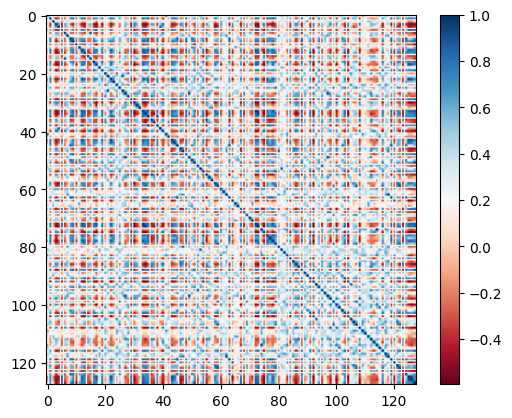

In [23]:
from matplotlib import pyplot as plt
import matplotlib


%matplotlib inline


plt.imshow(lib_match, cmap='RdBu')
plt.colorbar()
plt.show()